Imports


In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")
target_names = iris.target_names

In [3]:
print("Dataset shape:", X.shape)
print("Target distribution:\n", y.value_counts().sort_index())
print("\nFeature sample:\n", X.head())

Dataset shape: (150, 4)
Target distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64

Feature sample:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


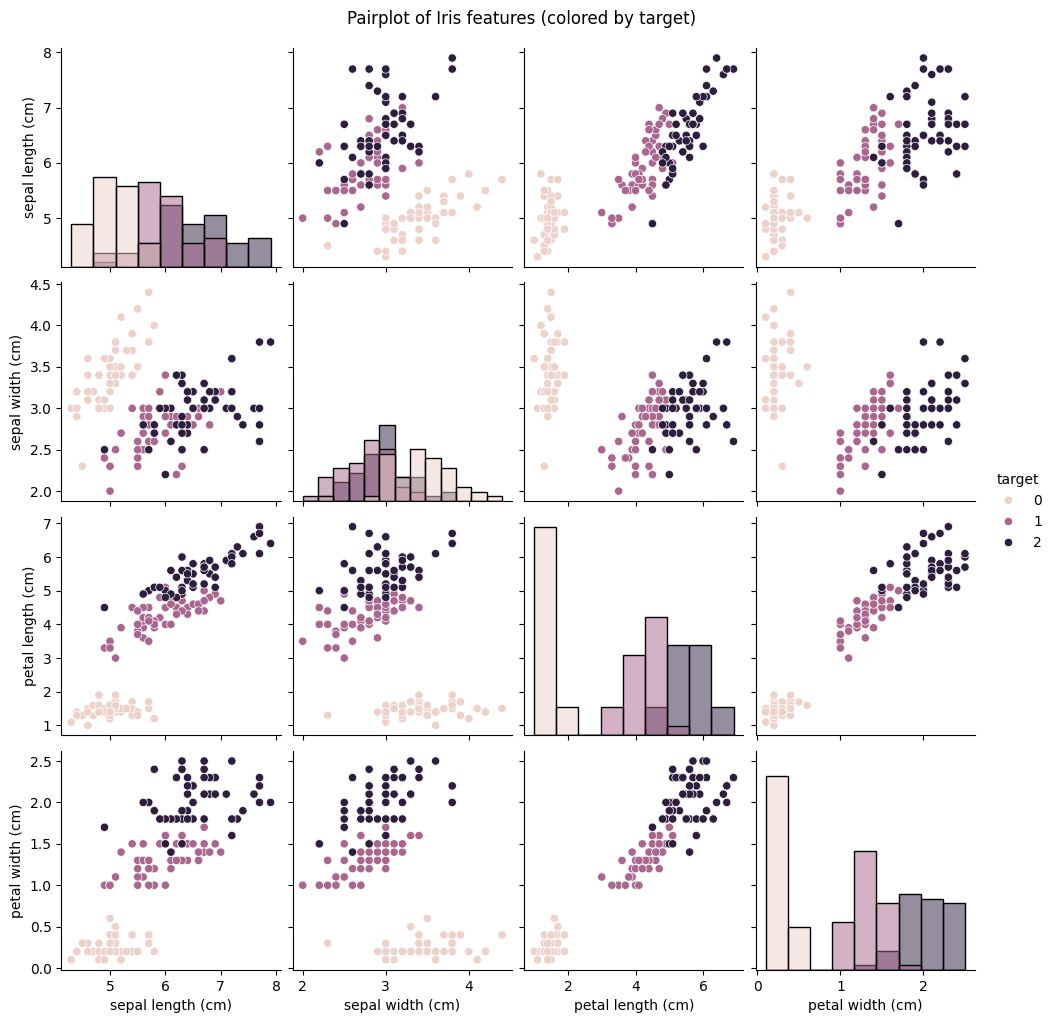

In [4]:
sns.pairplot(pd.concat([X, y], axis=1), hue="target", diag_kind="hist")
plt.suptitle("Pairplot of Iris features (colored by target)", y=1.02)
plt.show()

In [5]:
X = X.copy()
X["sepal_length_to_width"] = X["sepal length (cm)"] / (X["sepal width (cm)"] + 1e-8)
X["petal_length_to_width"] = X["petal length (cm)"] / (X["petal width (cm)"] + 1e-8)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain shape: {x_train.shape}; Test shape: {x_test.shape}")


Train shape: (112, 6); Test shape: (38, 6)


In [7]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [8]:
cv_scores = cross_val_score(pipe_knn, x_train, y_train, cv=5, scoring="accuracy")
print(f"\nKNN CV (5-fold) mean accuracy (baseline): {cv_scores.mean():.4f}")


KNN CV (5-fold) mean accuracy (baseline): 0.9368


In [9]:
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"]
}
grid_knn = GridSearchCV(pipe_knn, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_knn.fit(x_train, y_train)
print(f"\nBest KNN params: {grid_knn.best_params_}")
print(f"Best KNN CV score: {grid_knn.best_score_:.4f}")


Best KNN params: {'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best KNN CV score: 0.9549


In [10]:
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 3, 5],
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(x_train, y_train)
print(f"\nBest RF params: {grid_rf.best_params_}")
print(f"Best RF CV score: {grid_rf.best_score_:.4f}")


Best RF params: {'rf__max_depth': None, 'rf__n_estimators': 100}
Best RF CV score: 0.9553



KNN Test Accuracy: 0.9211
Random Forest Test Accuracy: 0.9211

Selected Best Model: RandomForest


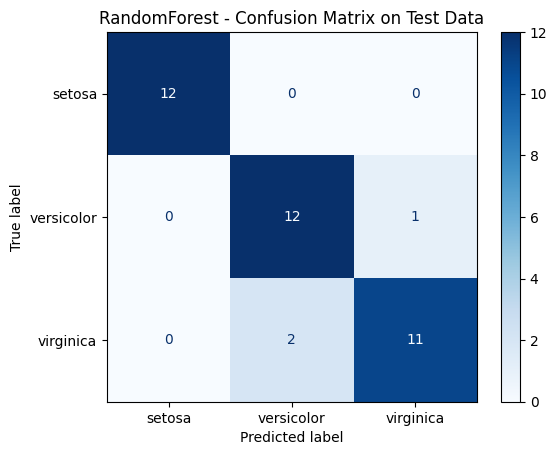


Classification Report for RandomForest:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [13]:
best_knn = grid_knn.best_estimator_
best_rf = grid_rf.best_estimator_

knn_predictions = best_knn.predict(x_test)
rf_predictions = best_rf.predict(x_test)

knn_acc = accuracy_score(y_test, knn_predictions)
rf_acc = accuracy_score(y_test, rf_predictions)

print(f"\nKNN Test Accuracy: {knn_acc:.4f}")
print(f"Random Forest Test Accuracy: {rf_acc:.4f}")

if rf_acc >= knn_acc:
    best_model = best_rf
    best_name = "RandomForest"
else:
    best_model = best_knn
    best_name = "KNN"

print(f"\nSelected Best Model: {best_name}")

cm = confusion_matrix(y_test, best_model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"{best_name} - Confusion Matrix on Test Data")
plt.show()

print(f"\nClassification Report for {best_name}:\n")
print(classification_report(y_test, best_model.predict(x_test), target_names=target_names))

In [15]:
model_filename = "iris_model.pkl"
with open(model_filename, "wb") as f:
    pickle.dump({
        "model": best_model,
        "feature_names": list(X.columns),
        "target_names": target_names.tolist(),
    }, f)
print(f"\nSaved final model to {model_filename}")


Saved final model to iris_model.pkl
